EXPERIMENT 06 - TASK 02
K-Means Clustering
Name    : R. Karthik
Roll No : 25EU02904

Dataset Shape:
(150, 4)

WCSS Values:
k=1: 600.0000
k=2: 222.3617
k=3: 139.8205
k=4: 114.0925
k=5: 90.9275
k=6: 81.5444
k=7: 72.6311
k=8: 62.5406
k=9: 55.1195
k=10: 47.3910


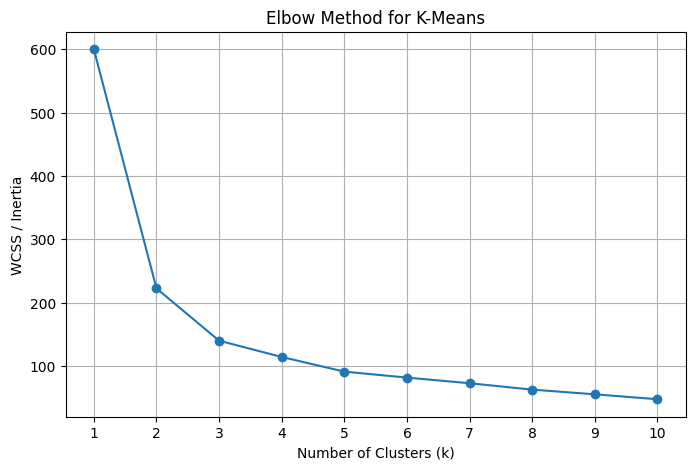


Silhouette Scores:
k=2: 0.5818
k=3: 0.4599
k=4: 0.3869
k=5: 0.3459
k=6: 0.3171

Best k according to Silhouette Score: 2
Best Silhouette Score: 0.5818

First 10 Cluster Assignments:
[1 1 1 1 1 1 1 1 1 1]

Cluster Centroids:
           sepal length (cm)  sepal width (cm)  petal length (cm)  \
Cluster 0           5.801887          2.673585           4.369811   
Cluster 1           5.006000          3.428000           1.462000   
Cluster 2           6.780851          3.095745           5.510638   

           petal width (cm)  
Cluster 0          1.413208  
Cluster 1          0.246000  
Cluster 2          1.972340  


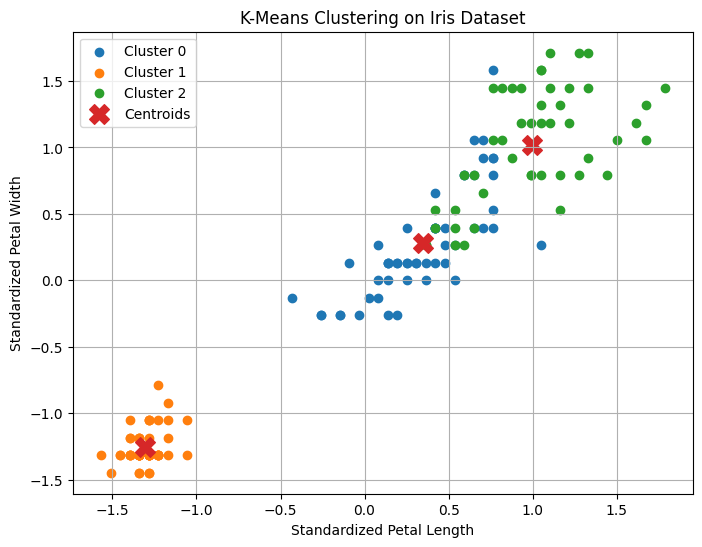


TASK 02 COMPLETED SUCCESSFULLY
K-Means clustering was applied to the Iris dataset.
Name    : R. Karthik
Roll No : 25EU02904


In [1]:
# ============================================================
# EXPERIMENT 06 - TASK 02
# K-Means Clustering
#
# Name    : R. Karthik
# Roll No : 25EU02904
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("=" * 60)
print("EXPERIMENT 06 - TASK 02")
print("K-Means Clustering")
print("Name    : R. Karthik")
print("Roll No : 25EU02904")
print("=" * 60)

# ------------------------------------------------------------
# 1. Load Iris Dataset
# ------------------------------------------------------------

iris = load_iris()

X = iris.data
y = iris.target

target_names = iris.target_names

print("\nDataset Shape:")
print(X.shape)

# ------------------------------------------------------------
# 2. Standardize Features
# ------------------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X
)

# ------------------------------------------------------------
# 3. Elbow Method
# ------------------------------------------------------------

wcss = []

k_values = range(
    1,
    11
)

for k in k_values:

    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=42
    )

    model.fit(
        X_scaled
    )

    wcss.append(
        model.inertia_
    )

print("\nWCSS Values:")

for k, value in zip(
    k_values,
    wcss
):
    print(
        f"k={k}: {value:.4f}"
    )

# Elbow graph
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    k_values,
    wcss,
    marker="o"
)

plt.xlabel(
    "Number of Clusters (k)"
)

plt.ylabel(
    "WCSS / Inertia"
)

plt.title(
    "Elbow Method for K-Means"
)

plt.xticks(
    list(k_values)
)

plt.grid(True)

plt.show()

# ------------------------------------------------------------
# 4. Silhouette Analysis
# ------------------------------------------------------------

silhouette_scores = []

k_eval = range(
    2,
    7
)

for k in k_eval:

    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        random_state=42
    )

    labels = model.fit_predict(
        X_scaled
    )

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(
        score
    )

print("\nSilhouette Scores:")

for k, score in zip(
    k_eval,
    silhouette_scores
):
    print(
        f"k={k}: {score:.4f}"
    )

best_k = list(k_eval)[
    np.argmax(silhouette_scores)
]

best_score = max(
    silhouette_scores
)

print(
    f"\nBest k according to Silhouette Score: "
    f"{best_k}"
)

print(
    f"Best Silhouette Score: "
    f"{best_score:.4f}"
)

# ------------------------------------------------------------
# 5. Final K-Means Model
# ------------------------------------------------------------

kmeans = KMeans(
    n_clusters=3,
    init="k-means++",
    n_init=10,
    random_state=42
)

cluster_labels = kmeans.fit_predict(
    X_scaled
)

print("\nFirst 10 Cluster Assignments:")

print(
    cluster_labels[:10]
)

# ------------------------------------------------------------
# 6. Cluster Centroids
# ------------------------------------------------------------

centroids_scaled = (
    kmeans.cluster_centers_
)

centroids_original = (
    scaler.inverse_transform(
        centroids_scaled
    )
)

centroid_df = pd.DataFrame(
    centroids_original,
    columns=iris.feature_names
)

centroid_df.index = [
    "Cluster 0",
    "Cluster 1",
    "Cluster 2"
]

print("\nCluster Centroids:")
print(
    centroid_df
)

# ------------------------------------------------------------
# 7. Visualize Clusters
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 6)
)

for cluster in range(3):

    mask = cluster_labels == cluster

    plt.scatter(
        X_scaled[mask, 2],
        X_scaled[mask, 3],
        label=f"Cluster {cluster}"
    )

# Plot centroids
plt.scatter(
    centroids_scaled[:, 2],
    centroids_scaled[:, 3],
    marker="X",
    s=200,
    label="Centroids"
)

plt.xlabel(
    "Standardized Petal Length"
)

plt.ylabel(
    "Standardized Petal Width"
)

plt.title(
    "K-Means Clustering on Iris Dataset"
)

plt.legend()

plt.grid(True)

plt.show()

# ------------------------------------------------------------
# Conclusion
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TASK 02 COMPLETED SUCCESSFULLY")
print("K-Means clustering was applied to the Iris dataset.")
print("Name    : R. Karthik")
print("Roll No : 25EU02904")
print("=" * 60)